<a href="https://colab.research.google.com/github/glafica/GL_Data_Lab/blob/main/An%C3%A1lisis%20de%20Datos%20con%20Python/2024%20Big%20Data%20con%20Python/(Final)_TP_Parte_II.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **IMPORTACION DE LIBRERIAS Y OBTENCION DE DATOS:**

In [181]:
import pandas as pd
import numpy as np

ID_planilla = "1wq-nFom22x7wv38QcjE__1u-z7XtEjJb8oCgyMxRLoQ"
URL = f'https://docs.google.com/spreadsheets/d/{ID_planilla}/gviz/tq?tqx=out:csv&sheet='

df_sales = pd.read_csv(URL + 'sales_in_paraguay')
df_distributors = pd.read_csv(URL + 'distributors_profiles')
df_exports = pd.read_csv(URL + 'exports_to_Paraguay')
df_locations = pd.read_csv(URL + 'locations_profiles')

# **1) LIMPIEZA DE DATOS**

## **Exploracion y limpieza de datos de df_exports👇**

In [182]:
print(df_exports.dtypes) # Explorar el tipo de dato de las columnas
print()
print(df_exports.head()) # Exploremos las primeras la filas de datos para saber con qué estamos lidiando:

distributor    float64
Rubber          object
Brass           object
Vinyl           object
Granite         object
Stone           object
Brick           object
Aluminum        object
Glass           object
Plexiglass      object
Steel           object
Wood            object
Plastic         object
Unnamed: 13    float64
Unnamed: 14     object
Columnas        object
dtype: object

   distributor          Rubber           Brass           Vinyl  \
0        1.526  $22.431.099,00  $36.031.577,00  $31.118.167,00   
1        1.553  $27.566.922,00  $21.996.538,00  $39.412.316,00   
2        1.666  $37.577.095,00  $41.457.655,00  $31.467.967,00   
3      364.000  $36.012.730,00  $41.667.692,00  $22.837.073,00   
4      920.000  $43.416.417,00  $36.290.780,00  $23.679.738,00   

          Granite           Stone           Brick        Aluminum  \
0  $21.322.223,00  $35.382.848,00  $35.280.292,00  $32.362.235,00   
1  $25.681.987,00  $41.861.783,00  $22.408.742,00  $40.690.302,00   
2  $37.577.92

In [183]:
cols_a_eliminar = ["Unnamed: 13", "Unnamed: 14", "Columnas"] # Eliminamos las columnas que no van

df_exports.drop(columns=[c for c in cols_a_eliminar if c in df_exports.columns], inplace=True) # Esto solo intenta borrar las que realmente existan en el DataFrame
print(df_exports.head())


   distributor          Rubber           Brass           Vinyl  \
0        1.526  $22.431.099,00  $36.031.577,00  $31.118.167,00   
1        1.553  $27.566.922,00  $21.996.538,00  $39.412.316,00   
2        1.666  $37.577.095,00  $41.457.655,00  $31.467.967,00   
3      364.000  $36.012.730,00  $41.667.692,00  $22.837.073,00   
4      920.000  $43.416.417,00  $36.290.780,00  $23.679.738,00   

          Granite           Stone           Brick        Aluminum  \
0  $21.322.223,00  $35.382.848,00  $35.280.292,00  $32.362.235,00   
1  $25.681.987,00  $41.861.783,00  $22.408.742,00  $40.690.302,00   
2  $37.577.926,00  $35.845.106,00  $42.953.168,00  $33.817.289,00   
3  $29.288.200,00  $39.553.494,00  $33.513.588,00  $36.827.718,00   
4  $21.183.706,00  $25.210.622,00  $30.864.041,00  $41.173.207,00   

            Glass         Plexiglass           Steel            Wood  \
0  $36.836.190,00  $9.440.858.902,00  $34.676.425,00  $31.862.742,00   
1  $37.958.885,00  $8.726.744.768,00  $26.47

In [184]:
df_exports['distributor'] = df_exports['distributor'].astype(str) # Cambiamos distributors a string para poder modificarlo

# Eliminar símbolos de $ y cambiar comas por puntos:
# 1) Las cargamos en una lista
columnas = df_exports.columns
# 2) Utilizamos un bucle para aplicar los métodos de reemplazo que podamos
for col in columnas:
    if df_exports[col].dtype == 'object':
       df_exports[col] = df_exports[col].str.replace("$","") # eliminar $
       df_exports[col] = df_exports[col].str.replace(".","") # eliminar puntos
       df_exports[col] = df_exports[col].str.replace(",",".") # cambiar comas por puntos

print(df_exports.head())
print(df_exports.dtypes)


  distributor       Rubber        Brass        Vinyl      Granite  \
0        1526  22431099.00  36031577.00  31118167.00  21322223.00   
1        1553  27566922.00  21996538.00  39412316.00  25681987.00   
2        1666  37577095.00  41457655.00  31467967.00  37577926.00   
3        3640  36012730.00  41667692.00  22837073.00  29288200.00   
4        9200  43416417.00  36290780.00  23679738.00  21183706.00   

         Stone        Brick     Aluminum        Glass     Plexiglass  \
0  35382848.00  35280292.00  32362235.00  36836190.00  9440858902.00   
1  41861783.00  22408742.00  40690302.00  37958885.00  8726744768.00   
2  35845106.00  42953168.00  33817289.00  41602183.00  1223232055.00   
3  39553494.00  33513588.00  36827718.00  29669764.00    44858747.00   
4  25210622.00  30864041.00  41173207.00  36719169.00    43893114.00   

         Steel         Wood      Plastic  
0  34676425.00  31862742.00  32588556.00  
1  26472020.00  27403955.00  37881851.00  
2  30599951.00  4051474

In [185]:
# Convertimos los tipos de datos de las columnas a float y del id a int:
columnas = list(df_exports.columns[1:])
for col in columnas:
  df_exports[col] = df_exports[col].astype(float)
df_exports['distributor'] = df_exports['distributor'].astype(int)

print(df_exports.dtypes)
print(df_exports.head())

distributor      int64
Rubber         float64
Brass          float64
Vinyl          float64
Granite        float64
Stone          float64
Brick          float64
Aluminum       float64
Glass          float64
Plexiglass     float64
Steel          float64
Wood           float64
Plastic        float64
dtype: object
   distributor      Rubber       Brass       Vinyl     Granite       Stone  \
0         1526  22431099.0  36031577.0  31118167.0  21322223.0  35382848.0   
1         1553  27566922.0  21996538.0  39412316.0  25681987.0  41861783.0   
2         1666  37577095.0  41457655.0  31467967.0  37577926.0  35845106.0   
3         3640  36012730.0  41667692.0  22837073.0  29288200.0  39553494.0   
4         9200  43416417.0  36290780.0  23679738.0  21183706.0  25210622.0   

        Brick    Aluminum       Glass    Plexiglass       Steel        Wood  \
0  35280292.0  32362235.0  36836190.0  9.440859e+09  34676425.0  31862742.0   
1  22408742.0  40690302.0  37958885.0  8.726745e+09  2647202

In [186]:
# 1. Averiguar cúantos valores duplicados hay -> 2 duplicados
df_exports.duplicated().sum()

np.int64(2)

In [187]:
# 2. Identificarlos, cargando los id de país duplicados en una lista
export_dups = df_exports[df_exports['distributor'].duplicated(keep=False)]['distributor'].tolist()
print(export_dups)

[3250, 1169, 1169, 3250]


In [188]:
# 3. Verificar
print(df_exports[df_exports.iloc[:].duplicated(keep=False)])

    distributor      Rubber       Brass       Vinyl     Granite       Stone  \
11         3250  25138331.0  38634366.0  35724628.0  21355595.0  42958842.0   
13         1169  38180046.0  28960197.0  38400970.0  23646886.0  39383770.0   
19         1169  38180046.0  28960197.0  38400970.0  23646886.0  39383770.0   
41         3250  25138331.0  38634366.0  35724628.0  21355595.0  42958842.0   

          Brick    Aluminum       Glass  Plexiglass       Steel        Wood  \
11   27048824.0  32985225.0  33904151.0  38767257.0  31216833.0  24977157.0   
13  122710022.0  39875739.0  29282534.0  38309291.0  40723171.0  27897700.0   
19  122710022.0  39875739.0  29282534.0  38309291.0  40723171.0  27897700.0   
41   27048824.0  32985225.0  33904151.0  38767257.0  31216833.0  24977157.0   

       Plastic  
11  39193942.0  
13  23071801.0  
19  23071801.0  
41  39193942.0  


In [189]:
# 4. Eliminar los registros duplicados
print(len(df_exports)) # antes
df_exports = df_exports.drop_duplicates()
print(len(df_exports)) # después

46
44


# **Exploracion y limpieza de datos de df_sales👇**

In [190]:
print(df_sales.info()) # Explorar el tipo de dato de las columnas
print(df_sales.head()) # Exploremos las primeras la filas de datos para saber con qué estamos lidiando:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   distributor  44 non-null     float64
 1   Rubber       45 non-null     object 
 2   Brass        45 non-null     object 
 3   Vinyl        45 non-null     object 
 4   Granite      45 non-null     object 
 5   Stone        45 non-null     object 
 6   Brick        45 non-null     object 
 7   Aluminum     45 non-null     object 
 8   Glass        45 non-null     object 
 9   Plexiglass   45 non-null     object 
 10  Steel        45 non-null     object 
 11  Wood         45 non-null     object 
 12  Plastic      45 non-null     object 
 13  Unnamed: 13  0 non-null      float64
 14  Unnamed: 14  0 non-null      float64
 15  Unnamed: 15  0 non-null      float64
 16  Unnamed: 16  0 non-null      float64
 17  Unnamed: 17  0 non-null      float64
 18  Unnamed: 18  0 non-null      float64
 19  Unnamed: 1

In [191]:
# Eliminamos las columnas que no corresponden
columnas = list(df_sales.columns[1:])
df_sales.drop(columns = df_sales[columnas[12:]] , inplace = True)
print(df_sales. info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   distributor  44 non-null     float64
 1   Rubber       45 non-null     object 
 2   Brass        45 non-null     object 
 3   Vinyl        45 non-null     object 
 4   Granite      45 non-null     object 
 5   Stone        45 non-null     object 
 6   Brick        45 non-null     object 
 7   Aluminum     45 non-null     object 
 8   Glass        45 non-null     object 
 9   Plexiglass   45 non-null     object 
 10  Steel        45 non-null     object 
 11  Wood         45 non-null     object 
 12  Plastic      45 non-null     object 
dtypes: float64(1), object(12)
memory usage: 4.7+ KB
None


In [192]:
# Convertimos todos los valores de la columna 'distributor' a cadenas de texto
df_sales['distributor'] = df_sales['distributor'].astype(str)

In [193]:
# Buscamos los indices de los valores de id de distribuidor no numerico:
print(df_sales.index[(df_sales['distributor'].str.isalpha())].tolist())
print(df_sales)

[44]
   distributor             Rubber              Brass              Vinyl  \
0        583.0     $54.510.203,61     $45.268.636,86     $51.579.748,25   
1       1104.0     $32.438.788,20     $25.837.100,49     $36.603.264,50   
2       1384.0     $21.780.180,58     $78.927.599,01     $25.837.100,49   
3        379.0     $79.358.855,35     $90.185.311,22     $45.268.636,86   
4       1599.0     $11.758.005,07     $21.780.180,58     $57.187.306,41   
5       1062.0     $90.185.311,22     $43.512.922,94     $11.758.005,07   
6       1679.0     $78.927.599,01     $57.187.306,41     $41.899.590,44   
7       1302.0      $5.662.736,92     $59.862.809,01     $46.239.695,30   
8        565.0     $57.009.912,25     $53.172.624,14     $36.999.867,09   
9        860.0     $36.603.264,50     $54.510.203,61      $1.346.769,34   
10       707.0     $59.199.680,31     $59.199.680,31      $9.945.371,16   
11       846.0     $61.236.075,66     $32.067.534,68     $21.883.374,92   
12       175.0     $

In [194]:
# Verificamos que hay en esa fila
print(df_sales.loc[44])

distributor                   nan
Rubber          $1.680.453.941,34
Brass           $1.840.659.381,00
Vinyl           $1.912.589.120,61
Granite         $1.845.294.550,32
Stone           $1.651.519.395,68
Brick                 $152.658,00
Aluminum        $2.163.832.570,90
Glass           $2.173.275.882,80
Plexiglass     $25.974.040.668,75
Steel                  $58.458,00
Wood            $1.930.565.060,49
Plastic         $2.047.338.174,36
Name: 44, dtype: object


In [195]:
# Chequeamos si corresponde al total:
print(df_sales.iloc[0:43,1].sum())
print(df_sales.iloc[44,1])
# Eliminamos ese ID no numerico (que correspondia al total)
#df_sales.drop([44], inplace = True)
#print(df_sales.tail(1))

$54.510.203,61$32.438.788,20$21.780.180,58$79.358.855,35$11.758.005,07$90.185.311,22$78.927.599,01$5.662.736,92$57.009.912,25$36.603.264,50$59.199.680,31$61.236.075,66$26.576.776,52$59.862.809,01$33.102.840,61$1.346.769,34$45.268.636,86$20.344.007,84$77.874.267,01$42.411.396,23$10.536.882,23$46.239.695,30$51.579.748,25$41.572.788,80$16.086.016,33$35.563.624,11$22.300.838,58$21.883.374,92$53.172.624,14$41.899.599,44$32.067.534,68$11.812.951,32$57.187.306,41$1.473.437,08$55.020.982,80$18.050.385,12$27.179.878,86$25.837.100,49$43.512.922,94$9.945.371,16$3.221.765,13$36.999.867,09$55.872.547,77
$1.680.453.941,34


In [196]:
# Eliminar símbolos de $ y cambiar comas por puntos
columnas = list(df_sales.columns[1:]) # Las cargamos en una lista
# Utilizamos un bucle para aplicar los métodos de reemplazo que podamos

for col in columnas:
  # Llenamos valores nulos con una cadena vacía y convertimos a cadenas de texto
    df_sales[col] = df_sales[col].fillna('').astype(str)
    df_sales[col] = df_sales[col].str.replace('$','') # eliminar $
    df_sales[col] = df_sales[col].str.replace('.','') # eliminar puntos
    df_sales[col] = df_sales[col].str.replace(',','.') # cambiar comas por puntos

print(df_sales.head())

  distributor       Rubber        Brass        Vinyl      Granite  \
0       583.0  54510203.61  45268636.86  51579748.25  21780180.58   
1      1104.0  32438788.20  25837100.49  36603264.50  21883374.92   
2      1384.0  21780180.58  78927599.01  25837100.49  33102840.61   
3       379.0  79358855.35  90185311.22  45268636.86  54510203.61   
4      1599.0  11758005.07  21780180.58  57187306.41   9945371.16   

         Stone Brick     Aluminum        Glass     Plexiglass    Steel  \
0  26576776.52  0.00  55872547.77  18050385.12   178927599.01  2788.80   
1   1473437.08  0.00  46239695.30  33102840.61    35563624.11   599.01   
2  51579748.25  0.00  21883374.92  78927599.01     1346769.34     0.00   
3  59358855.35  0.00  79358855.35  32067534.68    53172624.14  2922.94   
4  32067534.68  0.00  53172624.14  57187306.41  1155872547.77   203.61   

          Wood    Plastic  
0  54510203.61   20982.80  
1   9945371.16  187306.41  
2  36603264.50  300838.58  
3  33102840.61  579748.25  


In [197]:
# Convertimos los tipos de datos de las columnas a float y del distribuidor a str para poder modificarlo:

columnas = list(df_sales.columns[1:])
for col in columnas:
  df_sales[col] = df_sales[col].astype(float)
df_sales['distributor'] = df_sales['distributor'].astype(str)
print(df_sales.info())
print(df_sales.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   distributor  45 non-null     object 
 1   Rubber       45 non-null     float64
 2   Brass        45 non-null     float64
 3   Vinyl        45 non-null     float64
 4   Granite      45 non-null     float64
 5   Stone        45 non-null     float64
 6   Brick        45 non-null     float64
 7   Aluminum     45 non-null     float64
 8   Glass        45 non-null     float64
 9   Plexiglass   45 non-null     float64
 10  Steel        45 non-null     float64
 11  Wood         45 non-null     float64
 12  Plastic      45 non-null     float64
dtypes: float64(12), object(1)
memory usage: 4.7+ KB
None
  distributor       Rubber        Brass        Vinyl      Granite  \
0       583.0  54510203.61  45268636.86  51579748.25  21780180.58   
1      1104.0  32438788.20  25837100.49  36603264.50  21883374.92   
2 

In [198]:
# Asegurarnos de que la columna 'distributor' sea de tipo float o tenga valores numéricos
df_sales['distributor'] = pd.to_numeric(df_sales['distributor'], errors='coerce')

# Llenar valores NaN resultantes de la conversión con un valor predeterminado, como 0
df_sales['distributor'] = df_sales['distributor'].fillna(0)

# Redondear los valores para convertirlos a enteros
df_sales['distributor'] = df_sales['distributor'].round().astype(int)

print(df_sales.dtypes)

distributor      int64
Rubber         float64
Brass          float64
Vinyl          float64
Granite        float64
Stone          float64
Brick          float64
Aluminum       float64
Glass          float64
Plexiglass     float64
Steel          float64
Wood           float64
Plastic        float64
dtype: object


In [199]:
# 1. Averiguar cúantos duplicados hay
print(df_sales.duplicated().sum()) # -> 0 No hay duplicados '''

0


# **Exploracion y limpieza de datos de df_distributors👇**

In [200]:
print(df_distributors.info()) # Explorar el tipo de dato de las columnas y datos vacios
print(f'\n{df_distributors.head()}') # Exploremos las primeras la filas de datos para saber con qué estamos lidiando:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                44 non-null     float64
 1   distributor                       44 non-null     object 
 2   distributor activities            44 non-null     object 
 3   years in the construction market  46 non-null     int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 1.6+ KB
None

        id        distributor  \
0  565.000    Abernathy-Hayes   
1    1.384     Balistreri LLC   
2    1.183  Brekke-Stiedemann   
3    1.526        Collins LLC   
4   29.000      Cummings-Ward   

                              distributor activities  \
0  construction materials import/distribution, ir...   
1  construction materials import/distribution, si...   
2         construction materials import/distribution   
3         construction materi

In [201]:
# Nos aseguramos de que la columna 'id' sea de tipo cadena
df_distributors['id'] = df_distributors['id'].astype(str)
# Buscamos duplicados
df_distributors.duplicated().sum()

# 2. Identificarlos, cargando los id duplicados en una lista
export_dups = df_distributors[df_distributors['id'].duplicated(keep=False)]['id'].tolist()
#print(df_distributors.iloc[export_dups])

# Buscamos los indices de los valores 'nan'
print(df_distributors.index[(df_distributors['id'].str.isalpha())].tolist())
# Eliminamos las filas de esos valores
df_distributors.drop([9,32], inplace= True)
print(df_distributors)


[9, 32]
       id                        distributor  \
0   565.0                    Abernathy-Hayes   
1   1.384                     Balistreri LLC   
2   1.183                  Brekke-Stiedemann   
3   1.526                        Collins LLC   
4    29.0                      Cummings-Ward   
5   1.055        Cummings, Kemmer and Walker   
6   1.093            Davis, Kiehn and Heller   
7   920.0         Denesik, Schmidt and Wyman   
8   1.062     Feil, MacGyver and Schamberger   
10  379.0                      Gerlach Group   
11  1.489                        Goldner Inc   
12  818.0          Grady, Kessler and Stokes   
13  707.0                       Haley-Larson   
14  504.0       Herman, Turcotte and Osinski   
15  715.0        Keebler, Deckow and Watsica   
16  619.0       Kerluke, Barrows and Murazik   
17  846.0                    Kertzmann-Nolan   
18  860.0                        Kling Group   
19  241.0               Koch, Lang and Mertz   
20  234.0       Koepp, Hessel an

In [215]:

df_distributors['id'] = df_distributors['id'].astype(str) # Cambiamos id a string para poder modificar
df_distributors['id'] = df_distributors['id'].str.replace('.000','') # Eliminamos ceros
df_distributors['id'] = df_distributors['id'].str.replace('.','') # Eliminamos puntos
print(df_distributors['id'])
print()
print()
print(df_distributors)

0     5650
1     1384
2     1183
3     1526
4      290
5     1055
6     1093
7     9200
8     1062
10    3790
11    1489
12    8180
13    7070
14    5040
15    7150
16    6190
17    8460
18    8600
19    2410
20    2340
21    1463
22    5830
23    1104
24    1750
25     171
26    1610
27    3250
28    1666
29    1553
30    1302
31    3640
33    1599
34    3080
35    8080
36    1017
37    8150
38    3780
39    1723
40    7230
41    1418
42    1235
43     156
44    1169
45    1679
Name: id, dtype: object


      id                        distributor  \
0   5650                    Abernathy-Hayes   
1   1384                     Balistreri LLC   
2   1183                  Brekke-Stiedemann   
3   1526                        Collins LLC   
4    290                      Cummings-Ward   
5   1055        Cummings, Kemmer and Walker   
6   1093            Davis, Kiehn and Heller   
7   9200         Denesik, Schmidt and Wyman   
8   1062     Feil, MacGyver and Schamberger   
10  3790            

In [216]:
df_distributors['id'] = df_distributors['id'].astype(int) # Modificamos el id a tipo entero
df_distributors.info()
print()
df_distributors.head(15)

<class 'pandas.core.frame.DataFrame'>
Index: 44 entries, 0 to 45
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   id                                44 non-null     int64 
 1   distributor                       44 non-null     object
 2   distributor activities            44 non-null     object
 3   years in the construction market  44 non-null     int64 
dtypes: int64(2), object(2)
memory usage: 1.7+ KB



,id,distributor,distributor activities,years in the construction market
0,5650,Abernathy-Hayes,"construction materials import/distribution, ir...",15
1,1384,Balistreri LLC,"construction materials import/distribution, si...",22
2,1183,Brekke-Stiedemann,construction materials import/distribution,13
3,1526,Collins LLC,construction materials import/distribution,12
4,290,Cummings-Ward,"construction materials import/distribution, ir...",23
5,1055,"Cummings, Kemmer and Walker","construction materials import/distribution, co...",23
6,1093,"Davis, Kiehn and Heller","construction materials import/distribution, ne...",12
7,9200,"Denesik, Schmidt and Wyman","construction materials import/distribution, zi...",18
8,1062,"Feil, MacGyver and Schamberger","construction materials import/distribution, \n...",20
10,3790,Gerlach Group,"construction materials import/distribution, el...",2


# **2) MODELADO DE DATOS:**


# **Unión de dataframes:** df_sales y df_exports 👇

In [204]:
print(df_sales)
#Ordenamos de menor a mayor los DF de Sales
df_sales = df_sales.sort_values('distributor')
df_sales.head()


    distributor        Rubber         Brass         Vinyl       Granite  \
0           583  5.451020e+07  4.526864e+07  5.157975e+07  2.178018e+07   
1          1104  3.243879e+07  2.583710e+07  3.660326e+07  2.188337e+07   
2          1384  2.178018e+07  7.892760e+07  2.583710e+07  3.310284e+07   
3           379  7.935886e+07  9.018531e+07  4.526864e+07  5.451020e+07   
4          1599  1.175801e+07  2.178018e+07  5.718731e+07  9.945371e+06   
5          1062  9.018531e+07  4.351292e+07  1.175801e+07  7.644400e+07   
6          1679  7.892760e+07  5.718731e+07  4.189959e+07  1.805039e+07   
7          1302  5.662737e+06  5.986281e+07  4.623970e+07  9.018531e+07   
8           565  5.700991e+07  5.317262e+07  3.699987e+07  5.919968e+07   
9           860  3.660326e+07  5.451020e+07  1.346769e+06  1.842180e+07   
10          707  5.919968e+07  5.919968e+07  9.945371e+06  5.587255e+07   
11          846  6.123608e+07  3.206753e+07  2.188337e+07  5.317262e+07   
12          175  2.657678

,distributor,Rubber,Brass,Vinyl,Granite,Stone,Brick,Aluminum,Glass,Plexiglass,Steel,Wood,Plastic
44,0,1.680454e+09,1.840659e+09,1.912589e+09,1.845295e+09,1.651519e+09,152658.0,2.163833e+09,2.173276e+09,2.597404e+10,58458.00,1.930565e+09,2.047338e+09
43,29,6.597858e+07,3.660326e+07,5.700991e+07,1.693145e+07,4.157279e+07,42458.0,1.246662e+07,9.945371e+06,1.778743e+08,0.00,9.018531e+07,3.251853e+08
23,161,4.157279e+07,3.556362e+07,2.717988e+07,7.935886e+07,1.346769e+06,13455.0,2.717988e+07,1.545102e+08,4.351292e+07,534.68,5.919968e+07,3.556362e+07
12,175,2.657678e+07,2.230084e+07,1.473437e+06,4.157279e+07,6.597858e+07,0.0,4.189959e+07,2.188337e+07,1.612361e+08,437.08,1.666294e+07,1.175801e+07
31,234,1.181295e+07,1.175801e+07,1.842180e+07,4.351292e+07,1.608602e+07,0.0,2.134677e+07,4.241140e+07,1.159200e+09,0.00,4.241140e+07,5.317262e+07


In [205]:
#Armamos los DF totales de ventas por producto

totales_ventas = df_sales.iloc[:,1:].sum().sort_values(ascending=False) #Los guardamos como series

totales_ventas = pd.DataFrame(totales_ventas, columns = ["Total_ventas"]) #Lo guardamos como DF
totales_ventas["Total_ventas"]/=1000000  #Lo convertimos a millones
totales_ventas.rename(columns={'Total_ventas':'Total_ventas(en millones)'}, inplace=True) #Lo renombramos
totales_ventas


,Total_ventas(en millones)
Plexiglass,51948.081337
Glass,4346.551766
Aluminum,4327.665142
Plastic,4094.676349
Wood,3861.130121
Vinyl,3825.178241
Granite,3690.589101
Brass,3681.318762
Rubber,3360.907883
Stone,3303.038791


In [206]:
#Armamos DF de Exportaciones por Productos
totales_exports = df_exports.iloc[:,1:].sum().sort_values(ascending=False)

totales_exports = pd.DataFrame (totales_exports, columns = ["Total_exports"])
totales_exports["Total_exports"]/=1000000 #Lo llevamos a millones
totales_exports.rename(columns={'Total_exports':'Total_exports(en millones)'}, inplace = True)
totales_exports

,Total_exports(en millones)
Plexiglass,20779.232535
Steel,13652.930026
Brick,5260.549009
Aluminum,1513.169630
Stone,1474.570889
Rubber,1465.042482
Plastic,1456.143794
Glass,1429.786765
Wood,1409.171577
Vinyl,1396.050453


In [207]:
#Acá hacemos el Merge
#Reseteamos los indices para hacer el Merge
totales_combinados = pd.merge(totales_exports.reset_index(), totales_ventas.reset_index(),on="index")
#Volvemos a setear los indices
totales_combinados.set_index("index", inplace=True)
totales_combinados

,Total_exports(en millones),Total_ventas(en millones)
index,,
Plexiglass,20779.232535,51948.081337
Steel,13652.930026,0.116916
Brick,5260.549009,0.305316
Aluminum,1513.169630,4327.665142
Stone,1474.570889,3303.038791
Rubber,1465.042482,3360.907883
Plastic,1456.143794,4094.676349
Glass,1429.786765,4346.551766
Wood,1409.171577,3861.130121


In [208]:
from google.colab import data_table
data_table.DataTable(totales_combinados, include_index=True, num_rows_per_page=10)

,Total_exports(en millones),Total_ventas(en millones)
index,,
Plexiglass,20779.232535,51948.081337
Steel,13652.930026,0.116916
Brick,5260.549009,0.305316
Aluminum,1513.169630,4327.665142
Stone,1474.570889,3303.038791
Rubber,1465.042482,3360.907883
Plastic,1456.143794,4094.676349
Glass,1429.786765,4346.551766
Wood,1409.171577,3861.130121


In [209]:
#Agregamos una columna para comparar Ventas y Exportaciones
totales_combinados['Ratio_ventas/exports'] = totales_combinados['Total_ventas(en millones)']/totales_combinados['Total_exports(en millones)']
totales_combinados

,Total_exports(en millones),Total_ventas(en millones),Ratio_ventas/exports
index,,,
Plexiglass,20779.232535,51948.081337,2.500000
Steel,13652.930026,0.116916,0.000009
Brick,5260.549009,0.305316,0.000058
Aluminum,1513.169630,4327.665142,2.860000
Stone,1474.570889,3303.038791,2.240000
Rubber,1465.042482,3360.907883,2.294069
Plastic,1456.143794,4094.676349,2.812000
Glass,1429.786765,4346.551766,3.040000
Wood,1409.171577,3861.130121,2.740000


## **3) ANALISIS VISUAL**

# **Gráficos:**
# Ventas Totales por Productos y Exportaciones Totales por Productos 👇

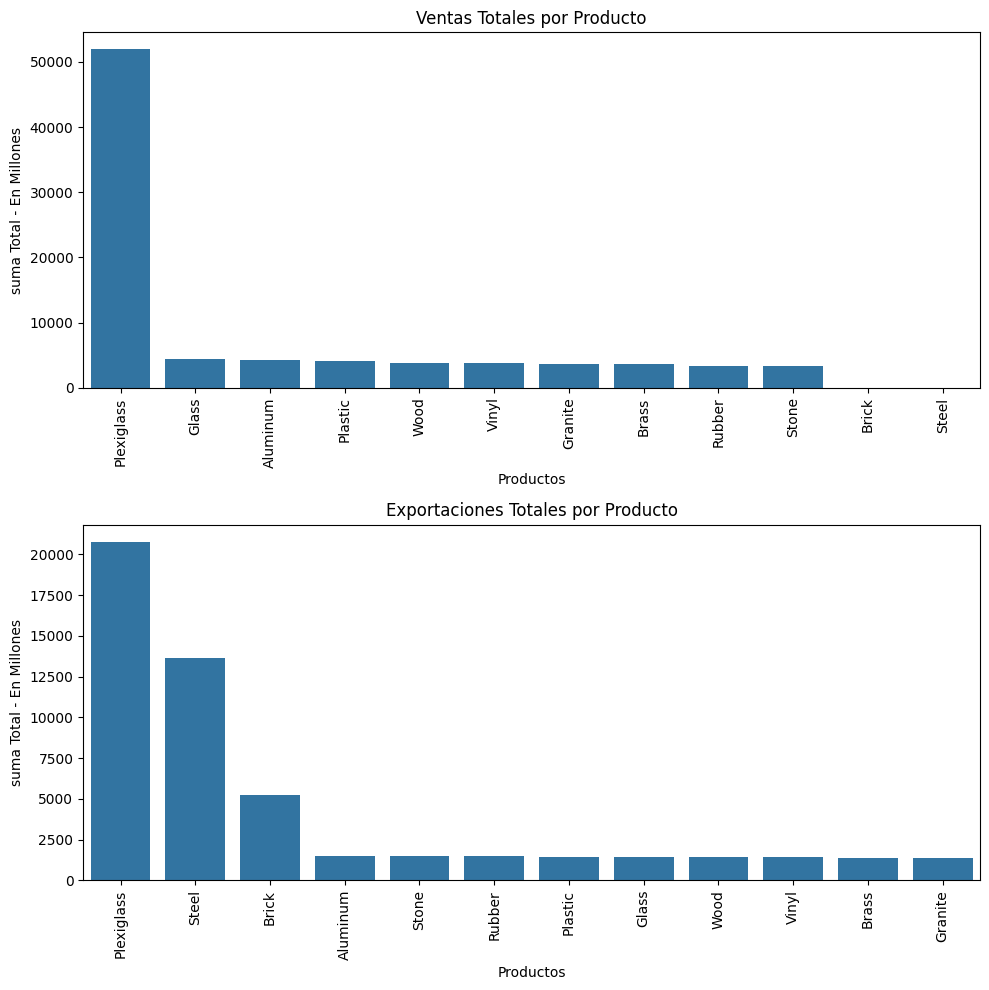

In [217]:
#graficamos los DF por separado VENTAS TOTALES POR PRODUCTO Y EXPORTACIONES TOTALES POR PRODUCTO

import matplotlib.pyplot as plt
import seaborn as sns

#Creamos los graficos

fig,axes = plt.subplots(nrows=2, ncols=1, figsize=(10,10))

#Graficamos las ventas

sns.barplot(x=totales_ventas.index, y=totales_ventas['Total_ventas(en millones)'], ax=axes[0])
axes[0].set_title('Ventas Totales por Producto')
axes[0].set_xlabel('Productos')
axes[0].set_ylabel('suma Total - En Millones')
axes[0].tick_params(axis='x', rotation=90) #Rotamos las etiquetas al eje de la x


#Grafico de Barras para export_py
sns.barplot(x=totales_exports.index, y=totales_exports['Total_exports(en millones)'], ax=axes[1])
axes[1].set_title('Exportaciones Totales por Producto')
axes[1].set_xlabel('Productos')
axes[1].set_ylabel('suma Total - En Millones')
axes[1].tick_params(axis='x', rotation=90) #Rotamos las etiquetas al eje de la x

#Ajustamos diseño
plt.tight_layout()
#Mostramos los Graficos
plt.show()

# **Gráfico:**
# Ratio de Ventas y Exportaciones por Productos 👇

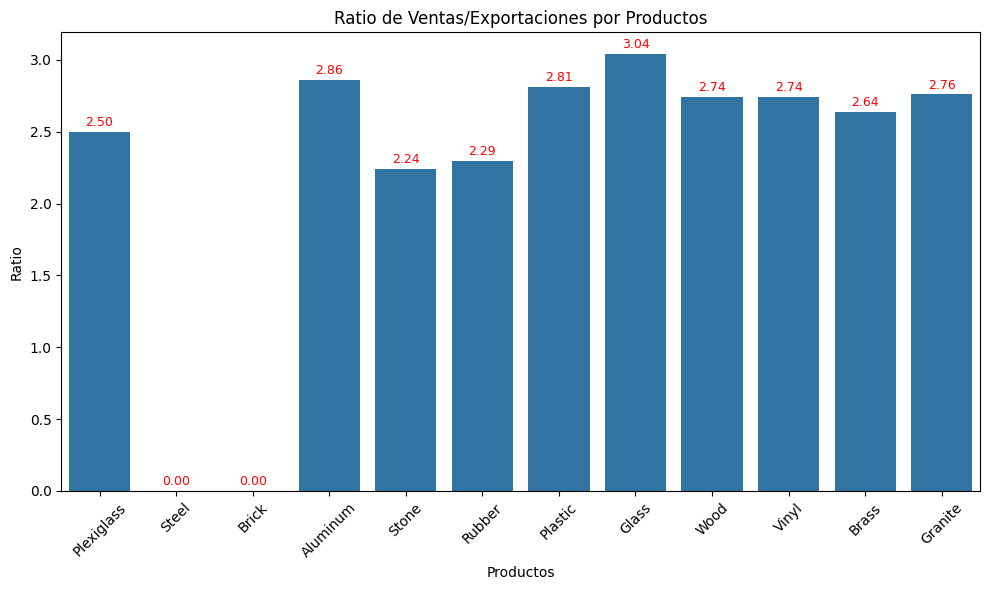

In [211]:
#Probamos graficar solo el ratio RATIO DE VENTAS/EXPORTACIONES POR PRODUCTOS

plt.figure(figsize=(10,6))
sns.barplot(x=totales_combinados.index, y='Ratio_ventas/exports', data=totales_combinados)

#Estilo
plt.title('Ratio de Ventas/Exportaciones por Productos')
plt.xlabel('Productos')
plt.ylabel('Ratio')
plt.xticks(rotation=45) #Rotamos las etiquetas del eje X

#Mostramos el valor de cada barra encima de ellas
for index, value in enumerate(totales_combinados['Ratio_ventas/exports']):
   plt.text(index, value + 0.02, f'{value:.2f}', ha='center', va='bottom', fontsize=9, color='red')

#Ajustamos el diseño del gráfico

plt.tight_layout()

#Mostramos los Gráficos
plt.show()

# **Gráfico:**
# Comparación: Total Ventas y Total Exportaciones por Indice 👇

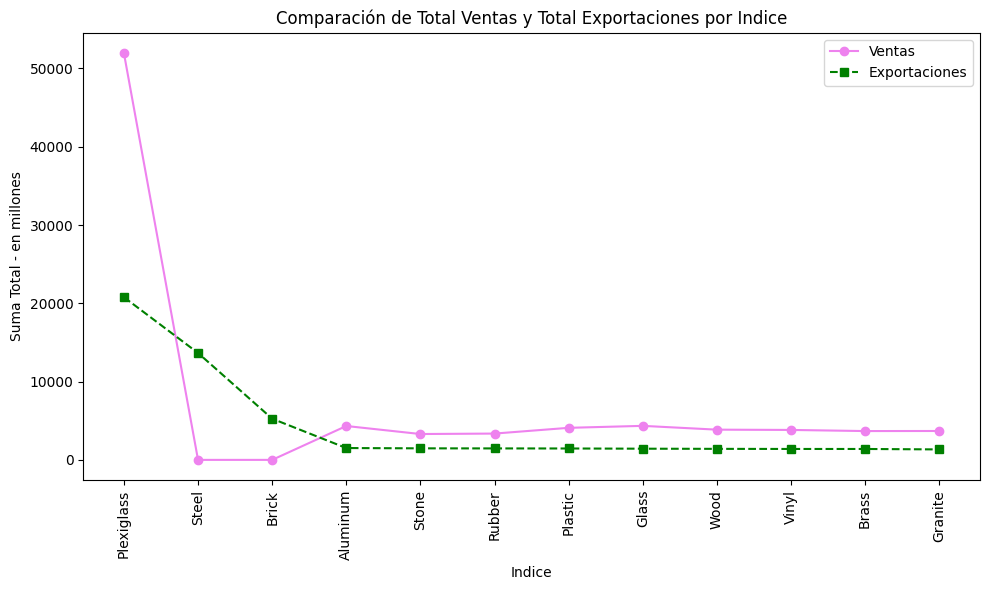

In [212]:
#Mostramos Gráfico de Líneas

plt.figure(figsize=(10,6))
plt.plot(totales_combinados.index, totales_combinados['Total_ventas(en millones)'], marker='o', linestyle ='-', color='violet' , label='Ventas')
plt.plot(totales_combinados.index, totales_combinados['Total_exports(en millones)'], marker='s', linestyle ='--', color='green' , label='Exportaciones')

plt.title('Comparación de Total Ventas y Total Exportaciones por Indice')
plt.xlabel('Indice')
plt.ylabel('Suma Total - en millones')
plt.xticks(rotation=90)
plt.legend()

plt.tight_layout()
plt.show()



## **Gráfico:**
# Comparación: Total Ventas y Total Exportaciones por Productos 👇

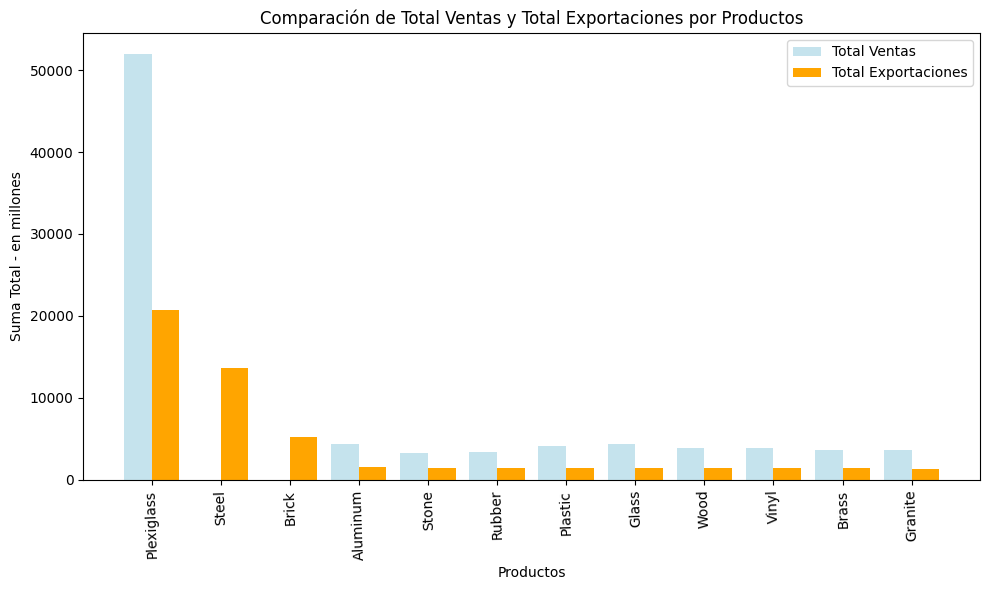

In [213]:
# Otro Gráfico

plt.figure(figsize=(10,6))
bar_width = 0.4
indices = range(len(totales_combinados))
plt.bar(indices, totales_combinados['Total_ventas(en millones)'], bar_width, label='Total Ventas', color='lightblue', alpha=0.7)
plt.bar([i + bar_width for i in indices], totales_combinados['Total_exports(en millones)'], bar_width, label='Total Exportaciones', color='orange')
plt.xlabel('Productos')
plt.ylabel('Suma Total - en millones')
plt.title('Comparación de Total Ventas y Total Exportaciones por Productos')
plt.xticks([i + bar_width/2 for i in indices], totales_combinados.index, rotation=92)
plt.legend()
plt.tight_layout()
plt.show()